<a href="https://colab.research.google.com/github/alk05/routing-comparison-nwm-nextgen-troute/blob/main/visualizing_outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Comparing NWM and Routing-Only datastream (and t-route)**

## Imports

In [ ]:
import xarray as xr
import pandas as pd
import json
import matplotlib.pyplot as plt
import ipywidgets as widgets
from numpy import select
import itertools
import matplotlib.cm as cm

## NWM

In [ ]:
# NWM dataset
# base_path = '/content/drive/MyDrive/Research/June19th04/'
base_path = '/content/drive/MyDrive/Research/Apr30th00/'

# first_nwm_filename = f'{base_path}nwm.t04z.short_range.channel_rt.f001.conus.nc'
first_nwm_filename = f'{base_path}nwm.t00z.short_range.channel_rt.f001.conus.nc'
with xr.open_dataset(first_nwm_filename) as ds_first:
    base_forecast_time = pd.to_datetime(ds_first.attrs['model_initialization_time'], format='%Y-%m-%d_%H:%M:%S', utc=True)

nwm_streamflows = []
for i in range(1, 19):
    hr_num = str(i).zfill(3) # Ensures f001, f002, ... format
    # filename = f'nwm.t04z.short_range.channel_rt.f{hr_num}.conus.nc'
    filename = f'nwm.t00z.short_range.channel_rt.f{hr_num}.conus.nc'
    ds = xr.open_dataset(base_path + filename)
    streamflow_da = ds['streamflow']

    valid_time = base_forecast_time + pd.Timedelta(hours=i)

    # Expand dimensions to add 'time' and assign the correct valid_time
    streamflow_da = streamflow_da.expand_dims(time=[valid_time])
    nwm_streamflows.append(streamflow_da)

nwm_flow = xr.concat(nwm_streamflows, dim='time')

## NextGen Routing-Only

In [ ]:
# NextGen Routing-only dataset
# df_ro = pd.read_parquet ('/content/drive/MyDrive/Research/June19th04/troute_output_202606190500.parquet')
df_ro = pd.read_parquet ('/content/drive/MyDrive/Research/Apr30th00/troute_output_202604300100.parquet')
# Ensure 'time' column is UTC-aware before setting as index
df_ro['time'] = pd.to_datetime(df_ro['time'], utc=True)
df_ro = df_ro.set_index(['feature_id', 'time'])
ds_ro = df_ro.to_xarray()
ro_flow = ds_ro['flow']

In [ ]:
# Crosswalk NWM and NextGen IDs
with open('/content/drive/MyDrive/Research/nwm_to_ngen_map.json', 'r') as f:
  mapping_dict = json.load(f)
convert_id = pd.Series(mapping_dict)

# print(convert_id['nex-492001'])

## T-Route

In [ ]:
# t_route
# df_t_route = pd.read_parquet('/content/drive/MyDrive/Research/June19th04/flowveldepth_2026-07-01T13:05:35.034852.parquet')
df_t_route = pd.read_parquet('/content/drive/MyDrive/Research/Apr30th00/flowveldepth_2026-07-01T11:03:51.645850.parquet')
df_t_route['value_time'] = pd.to_datetime(df_t_route['value_time'], utc=True)
df_t_route = df_t_route.set_index(['location_id','value_time'])

## Gage Data

In [ ]:
# Gage data
walnut_gage = pd.read_excel('/content/drive/MyDrive/Research/Apr30th00/walnut creek gage data.xlsx', usecols=['time', 'value'])
mulberry_gage = pd.read_excel('/content/drive/MyDrive/Research/Apr30th00/mulberry_creek_gage.xlsx', usecols=['time', 'value'])
cahaba_gage = pd.read_excel('/content/drive/MyDrive/Research/Apr30th00/cahaba river gage data.xlsx', usecols=['time', 'value'])

## Data Retrieval



In [ ]:
# data retrieval
def get_comparison_data(id, zero_threshold=0.2, selected_gage_df=None):

    ro_series = ro_flow.sel(feature_id=id).to_pandas()

    nwm_ids_raw = convert_id.get(f'nex-{str(id)}', [])
    filtered_nwm_data_dict = {} # Stores {nwm_id: nwm_series}
    filtered_nwm_ids = []
    nwm_series_list = []

    troute_data_dict = {} # Stores {troute_id: troute_series}
    troute_series_list = [] # For calculating the mean

    nwm_mean_series = None
    if nwm_ids_raw:
        for n_id in nwm_ids_raw:
            nwm_individual_series = nwm_flow.sel(feature_id=n_id).to_pandas() # Get series directly
            if not nwm_individual_series.empty and nwm_individual_series.max() > zero_threshold:
                filtered_nwm_ids.append(n_id)
                filtered_nwm_data_dict[f'nwm_flow_{int(n_id)}'] = nwm_individual_series
                nwm_series_list.append(nwm_individual_series)

        if nwm_series_list:
            # Concatenate series into a DataFrame and calculate mean along columns
            nwm_mean_series = pd.concat(nwm_series_list, axis=1, join='outer').mean(axis=1)

    if filtered_nwm_ids:
        for n_id in filtered_nwm_ids:
            troute_location_id = f'nex-{int(n_id)}'
            try:
                troute_streamflow_series = df_t_route.loc[(troute_location_id, slice(None)), :]
                troute_streamflow_series = troute_streamflow_series[troute_streamflow_series['variable_name'] == 'streamflow']['value']
                if not troute_streamflow_series.empty:
                    troute_streamflow_series = troute_streamflow_series.reset_index(level='location_id', drop=True)
                    troute_streamflow_series.index = pd.to_datetime(troute_streamflow_series.index)
                    # troute_streamflow_series_hourly = troute_streamflow_series.resample('h').mean()
                    if not troute_streamflow_series.isnull().all():
                        troute_data_dict[f't_route_{int(n_id)}'] = troute_streamflow_series
                        troute_series_list.append(troute_streamflow_series)
            except KeyError:
                pass

    troute_mean_series = None
    if troute_series_list:
        # Concatenate series into a DataFrame and calculate mean along columns
        troute_mean_series = pd.concat(troute_series_list, axis=1, join='outer').mean(axis=1)

    # Process gage data
    gage_data_series = None
    if selected_gage_df is not None and not selected_gage_df.empty:
        gage_df = selected_gage_df.copy()
        gage_df['time'] = pd.to_datetime(gage_df['time'], utc=True)
        gage_df = gage_df.set_index('time').sort_index()

        # Filter gage data for the requested time range.
        # start_time = pd.Timestamp('2026-06-19 04:00:00', tz='UTC')
        # end_time = pd.Timestamp('2026-06-19 22:00:00', tz='UTC')
        start_time = pd.Timestamp('2026-04-30 00:00:00', tz='UTC')
        end_time = pd.Timestamp('2026-04-30 19:00:00', tz='UTC')
        gage_df = gage_df.loc[start_time:end_time]
        gage_data_series = gage_df['value'] * 0.0283168 # convert to metric

    return ro_series, filtered_nwm_data_dict, nwm_mean_series, troute_data_dict, troute_mean_series,  gage_data_series

##Make Plot

In [ ]:
def plot_data(id, zero_threshold=0.2, selected_gage_df=None):
    plt.figure(figsize=(12, 7))

    ro_series, filtered_nwm_data_dict, nwm_mean_series, troute_data_dict, troute_mean_series, gage_data_series = \
        get_comparison_data(id, zero_threshold, selected_gage_df=selected_gage_df)

    # Colors for NWM and t_route
    nwm_colors = plt.cm.YlOrRd([0.3, 0.5, 0.7, 0.9])
    troute_colors = plt.cm.GnBu([0.3, 0.5, 0.7, 0.9])

    # Plot gage data
    if gage_data_series is not None and not gage_data_series.isnull().all():
        plt.plot(gage_data_series.index, gage_data_series.values, label='Gage Data', color='purple', linewidth=2, linestyle='-')

    # Plot NextGen routing-only
    plt.plot(ro_series.index, ro_series.values, label=f'NextGen {id}', color='black', linewidth=2)

    # Plot individual NWM
    nwm_color_cycle = itertools.cycle(nwm_colors)
    sorted_nwm_labels = sorted(filtered_nwm_data_dict.keys())
    for nwm_label in sorted_nwm_labels:
        nwm_individual_series = filtered_nwm_data_dict[nwm_label]
        nwm_id = int(nwm_label.replace('nwm_flow_', ''))
        plt.plot(nwm_individual_series.index, nwm_individual_series.values, label=f'NWM {nwm_id}', color=next(nwm_color_cycle), linestyle='--', alpha=0.7, linewidth=0.75)

    # Plot individual t_route
    troute_color_cycle = itertools.cycle(troute_colors)
    sorted_troute_labels = sorted(troute_data_dict.keys())
    for troute_label in sorted_troute_labels:
        troute_individual_series = troute_data_dict[troute_label]
        troute_nwm_id = int(troute_label.replace('t_route_', ''))
        plt.plot(troute_individual_series.index, troute_individual_series.values, label=f't_route {troute_nwm_id}', color=next(troute_color_cycle), linestyle='-', alpha=0.7, linewidth=0.75)

    # NWM average
    if nwm_mean_series is not None:
        plt.plot(nwm_mean_series.index, nwm_mean_series.values, label='NWM Average', color='red', linewidth=4, linestyle='-')

    # t-route average
    if troute_mean_series is not None:
        plt.plot(troute_mean_series.index, troute_mean_series.values, label='t_route Average', color='darkgreen', linewidth=5, linestyle='--')

    # Formatting
    title_components = [f'Flow Comparison for nex-{id}']
    plt.title(' '.join(title_components))
    plt.xlabel('Time')
    plt.ylabel('Flow Rate (m^3/s)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


##Combine to one DataFrame

In [ ]:
def combine_data_frames(id, zero_threshold=0.2, selected_gage_df=None):
    ro_series, filtered_nwm_data_dict, nwm_mean_series, troute_data_dict, troute_mean_series, gage_data_series = \
        get_comparison_data(id, zero_threshold, selected_gage_df=selected_gage_df)

    # Create a list of all series to merge
    all_series = []
    all_series.append(ro_series.rename('routing-only'))
    if troute_mean_series is not None:
        all_series.append(troute_mean_series.rename('t_route_flow_average'))
    if nwm_mean_series is not None:
        all_series.append(nwm_mean_series.rename('nwm_flow_average'))
    if gage_data_series is not None:
        all_series.append(gage_data_series.rename('gage_data'))

    for nwm_label, nwm_individual_series in filtered_nwm_data_dict.items():
        all_series.append(nwm_individual_series.rename(nwm_label))
    for troute_label, troute_individual_series in troute_data_dict.items():
        all_series.append(troute_individual_series.rename(troute_label))

    # Merge all series using their indices with an outer join to keep all time points
    flow_comparison = pd.concat(all_series, axis=1, join='outer')

    # Filter to only include 'on the hour' timestamps
    flow_comparison = flow_comparison[flow_comparison.index.minute == 0]

    return flow_comparison


## Show plot & dataframe

In [ ]:
def show_combined_info():
  id_str = input("Enter a NextGen ID: ")
  full_id_key = f'nex-{id_str}'
  if full_id_key in convert_id.index:
    id = int(id_str)
  else:
    print(f"Invalid ID number: {id_str}")
    return

  selected_gage_df = None
  if id == 497369:
      selected_gage_df = walnut_gage
  elif id == 497368:
      selected_gage_df = walnut_gage
  elif id == 492001:
      selected_gage_df = mulberry_gage
  elif id == 492000:
      selected_gage_df = mulberry_gage
  elif id == 491344:
      selected_gage_df = cahaba_gage
  elif id == 491343:
      selected_gage_df = cahaba_gage

  plot_data(id, selected_gage_df=selected_gage_df)
  print("\nCombined Flow Comparisons:")
  pd.set_option('display.max_columns', None) # display all columns.
  pd.set_option('display.max_rows', None)
  display(combine_data_frames(id, selected_gage_df=selected_gage_df))

  return

# Plots
Walnut Creek: 497369, 497368\
Mulberry Creek: 492001, 492000\
Cahaba River: 491344, 491343

Enter a NextGen ID: 497368


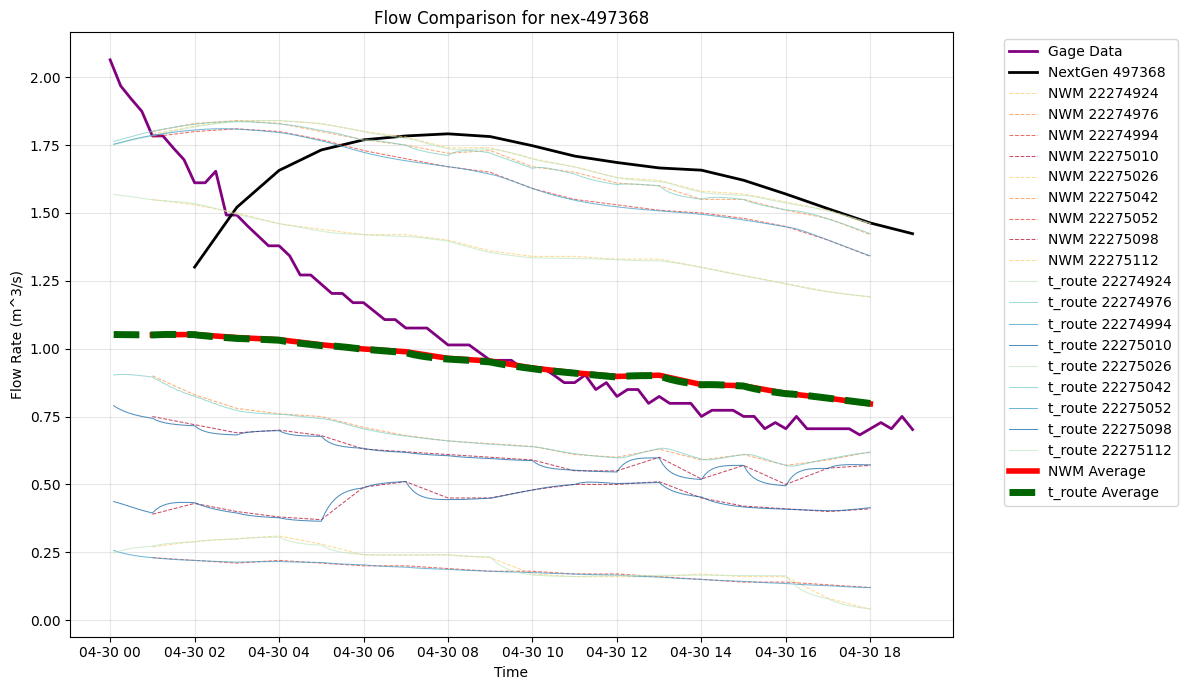


Combined Flow Comparisons:


,routing-only,t_route_flow_average,nwm_flow_average,gage_data,nwm_flow_22275010,nwm_flow_22275052,nwm_flow_22275042,nwm_flow_22274994,nwm_flow_22275026,nwm_flow_22274976,nwm_flow_22274924,nwm_flow_22275098,nwm_flow_22275112,t_route_22275010,t_route_22275052,t_route_22275042,t_route_22274994,t_route_22275026,t_route_22274976,t_route_22274924,t_route_22275098,t_route_22275112
2026-04-30 00:00:00+00:00,NaN,NaN,NaN,2.064295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-30 01:00:00+00:00,NaN,1.050642,1.051111,1.783958,0.75,0.23,0.90,1.78,1.55,1.80,1.79,0.39,0.27,0.743818,0.229993,0.895677,1.785806,1.548170,1.801035,1.784692,0.394657,0.271931
2026-04-30 02:00:00+00:00,1.300594,1.051685,1.052222,1.611226,0.72,0.22,0.83,1.80,1.53,1.83,1.82,0.43,0.29,0.715940,0.220041,0.824671,1.805825,1.534774,1.826584,1.816968,0.432606,0.287755
2026-04-30 03:00:00+00:00,1.520870,1.037711,1.041111,1.492295,0.69,0.21,0.78,1.81,1.50,1.84,1.84,0.40,0.30,0.682198,0.213644,0.773182,1.809031,1.494916,1.836408,1.837045,0.394620,0.298356
2026-04-30 04:00:00+00:00,1.656768,1.031143,1.033333,1.379028,0.70,0.22,0.76,1.80,1.46,1.83,1.84,0.38,0.31,0.697929,0.215933,0.758529,1.796195,1.460932,1.827971,1.839982,0.377057,0.305757
2026-04-30 05:00:00+00:00,1.732187,1.011240,1.014444,1.237444,0.68,0.21,0.75,1.77,1.44,1.80,1.83,0.37,0.28,0.676880,0.212398,0.742613,1.765623,1.433022,1.803493,1.826931,0.364174,0.276024
2026-04-30 06:00:00+00:00,1.769370,0.997824,0.998889,1.169484,0.63,0.20,0.71,1.73,1.42,1.77,1.80,0.49,0.24,0.632984,0.203608,0.704789,1.723463,1.419942,1.767625,1.799404,0.486999,0.241602
2026-04-30 07:00:00+00:00,1.783772,0.985608,0.988889,1.076038,0.62,0.20,0.68,1.70,1.42,1.75,1.78,0.51,0.24,0.618194,0.195023,0.677922,1.692268,1.412715,1.749629,1.774226,0.510715,0.239775
2026-04-30 08:00:00+00:00,1.791574,0.961634,0.964444,1.013741,0.61,0.19,0.66,1.67,1.40,1.72,1.74,0.45,0.24,0.605774,0.187057,0.660604,1.671026,1.396522,1.711695,1.737097,0.444028,0.240903
2026-04-30 09:00:00+00:00,1.781487,0.951059,0.954444,0.957108,0.60,0.18,0.65,1.65,1.36,1.73,1.74,0.45,0.23,0.595811,0.180689,0.648040,1.642707,1.354005,1.721228,1.734802,0.449253,0.232994


In [ ]:
show_combined_info()